# Arvato Customer Segmentation

Customer Segments is a market intelligence project
designed to optimize direct mail marketing for a
German retailer. The company needs to identify
which individuals within the general population are
most likely to become customers, rather than
sending costly marketing materials to everyone at
random.

***Goal is to use unsupervised learning to uncover the "DNA" of the existing customer base.***

#### **Project Plan**

| Phase | What needs to be done |
|-------|----------------------|
| **1** | Data Exploration |
| **2** | Preprocessing: Missing values, Feature Encoding, Single Automated Cleaning Function |
| **3** | Feature Transformation: Feature Scaling, PCA Implementation, Component Analysis |
| **4** | Clustering: K-Means Clustering, Customer Mapping, Market Profiling |

# Phase 1 — Data Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Libraries imported successfully!")

c:\Users\mnour\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Libraries imported successfully!


In [2]:
# Load General Demographics Data (AZDIAS)
data1 = pd.read_csv(r"C:\Users\mnour\Downloads\Data-20260414T060049Z-3-001\Data\Udacity_CUSTOMERS_Subset (2)\Udacity_AZDIAS_Subset.csv", sep=';')
print("Shape of AZDIAS:", data1.shape)
data1.head()

Shape of AZDIAS: (891221, 85)


,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,...,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,-1,2,1,2.0,3,4,3,5,5,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-1,1,2,5.0,1,5,2,5,4,5,...,2.0,3.0,2.0,1.0,1.0,5.0,4.0,3.0,5.0,4.0
2,-1,3,2,3.0,1,4,1,2,3,5,...,3.0,3.0,1.0,0.0,1.0,4.0,4.0,3.0,5.0,2.0
3,2,4,2,2.0,4,2,5,2,1,2,...,2.0,2.0,2.0,0.0,1.0,3.0,4.0,2.0,3.0,3.0
4,-1,3,1,5.0,4,3,4,1,3,2,...,2.0,4.0,2.0,1.0,2.0,3.0,3.0,4.0,6.0,5.0


In [3]:
# Load Customer Demographics Data
data2 = pd.read_csv(r"Task_14-20260411T100317Z-3-001\Task_14\Data\Udacity_CUSTOMERS_Subset.csv", sep=';')
print("Shape of CUSTOMERS:", data2.shape)
data2.head()

Shape of CUSTOMERS: (191652, 85)


,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,...,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,2,4,1,5.0,5,1,5,1,2,2,...,3.0,3.0,1.0,0.0,1.0,5.0,5.0,1.0,2.0,1.0
1,-1,4,1,NaN,5,1,5,1,3,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-1,4,2,2.0,5,1,5,1,4,4,...,2.0,3.0,3.0,1.0,3.0,3.0,2.0,3.0,5.0,3.0
3,1,4,1,2.0,5,1,5,2,1,2,...,3.0,2.0,1.0,0.0,1.0,3.0,4.0,1.0,3.0,1.0
4,-1,3,1,6.0,3,1,4,4,5,2,...,2.0,4.0,2.0,1.0,2.0,3.0,3.0,3.0,5.0,1.0


In [4]:
# Load Feature Summary
fsummary = pd.read_csv(r"C:\Users\mnour\Downloads\Data-20260414T060049Z-3-001\Data\Udacity_CUSTOMERS_Subset (2)\AZDIAS_Feature_Summary.csv", sep=";")
print("Feature summary shape:", fsummary.shape)
fsummary.head()

Feature summary shape: (85, 4)


,attribute,information_level,type,missing_or_unknown
0,AGER_TYP,person,categorical,"[-1,0]"
1,ALTERSKATEGORIE_GROB,person,ordinal,"[-1,0,9]"
2,ANREDE_KZ,person,categorical,"[-1,0]"
3,CJT_GESAMTTYP,person,categorical,[0]
4,FINANZ_MINIMALIST,person,ordinal,[-1]


In [5]:
# Basic statistics on both datasets
print("=== AZDIAS .describe() ===")
data1.describe()

=== AZDIAS .describe() ===


,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,...,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
count,891221.000000,891221.000000,891221.000000,886367.000000,891221.000000,891221.000000,891221.000000,891221.000000,891221.000000,891221.000000,...,774706.000000,774706.000000,774706.000000,774706.000000,774706.000000,774706.000000,774706.000000,794005.000000,794005.000000,794005.00000
mean,-0.358435,2.777398,1.522098,3.632838,3.074528,2.821039,3.401106,3.033328,2.874167,3.075121,...,2.253330,2.801858,1.595426,0.699166,1.943913,3.612821,3.381087,3.167854,5.293002,3.07222
std,1.198724,1.068775,0.499512,1.595021,1.321055,1.464749,1.322134,1.529603,1.486731,1.353248,...,0.972008,0.920309,0.986736,0.727137,1.459654,0.973967,1.111598,1.002376,2.303739,1.36298
min,-1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.00000
25%,-1.000000,2.000000,1.000000,2.000000,2.000000,1.000000,3.000000,2.000000,2.000000,2.000000,...,1.000000,2.000000,1.000000,0.000000,1.000000,3.000000,3.000000,3.000000,4.000000,2.00000
50%,-1.000000,3.000000,2.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,2.000000,3.000000,2.000000,1.000000,1.000000,4.000000,3.000000,3.000000,5.000000,3.00000
75%,-1.000000,4.000000,2.000000,5.000000,4.000000,4.000000,5.000000,5.000000,4.000000,4.000000,...,3.000000,3.000000,2.000000,1.000000,3.000000,4.000000,4.000000,4.000000,7.000000,4.00000
max,3.000000,9.000000,2.000000,6.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,4.000000,4.000000,3.000000,2.000000,5.000000,5.000000,5.000000,9.000000,9.000000,9.00000


In [6]:
print("=== CUSTOMERS .describe() ===")
data2.describe()

=== CUSTOMERS .describe() ===


,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,...,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
count,191652.000000,191652.000000,191652.000000,188439.000000,191652.000000,191652.000000,191652.000000,191652.000000,191652.000000,191652.000000,...,138888.000000,138888.000000,138888.000000,138888.000000,138888.000000,138888.000000,138888.000000,141176.000000,141176.000000,141176.000000
mean,0.344359,3.060907,1.376432,3.677928,3.963773,2.057051,4.183317,2.439808,2.646176,2.781176,...,2.537404,2.731510,1.388817,0.539939,1.556607,3.634893,3.622192,2.824850,5.119517,2.898510
std,1.391672,1.086254,0.484492,1.813975,1.036230,1.319422,0.995365,1.697932,1.586506,1.147353,...,0.904927,0.840922,0.885038,0.637048,1.185736,0.933660,1.008472,1.012415,2.159184,1.422683
min,-1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,-1.000000,3.000000,1.000000,2.000000,3.000000,1.000000,3.000000,1.000000,1.000000,2.000000,...,2.000000,2.000000,1.000000,0.000000,1.000000,3.000000,3.000000,2.000000,4.000000,2.000000
50%,0.000000,3.000000,1.000000,4.000000,4.000000,1.000000,5.000000,2.000000,2.000000,3.000000,...,3.000000,3.000000,1.000000,0.000000,1.000000,3.000000,4.000000,3.000000,5.000000,3.000000
75%,2.000000,4.000000,2.000000,6.000000,5.000000,4.000000,5.000000,5.000000,5.000000,3.000000,...,3.000000,3.000000,2.000000,1.000000,1.000000,4.000000,4.000000,4.000000,7.000000,4.000000
max,3.000000,9.000000,2.000000,6.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,4.000000,4.000000,3.000000,2.000000,5.000000,5.000000,5.000000,9.000000,9.000000,9.000000


In [7]:
print("=== AZDIAS .info() ===")
data1.info()

=== AZDIAS .info() ===
<class 'pandas.DataFrame'>
RangeIndex: 891221 entries, 0 to 891220
Data columns (total 85 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   AGER_TYP               891221 non-null  int64  
 1   ALTERSKATEGORIE_GROB   891221 non-null  int64  
 2   ANREDE_KZ              891221 non-null  int64  
 3   CJT_GESAMTTYP          886367 non-null  float64
 4   FINANZ_MINIMALIST      891221 non-null  int64  
 5   FINANZ_SPARER          891221 non-null  int64  
 6   FINANZ_VORSORGER       891221 non-null  int64  
 7   FINANZ_ANLEGER         891221 non-null  int64  
 8   FINANZ_UNAUFFAELLIGER  891221 non-null  int64  
 9   FINANZ_HAUSBAUER       891221 non-null  int64  
 10  FINANZTYP              891221 non-null  int64  
 11  GEBURTSJAHR            891221 non-null  int64  
 12  GFK_URLAUBERTYP        886367 non-null  float64
 13  GREEN_AVANTGARDE       891221 non-null  int64  
 14  HEALTH_TYP             8

In [8]:
print("=== CUSTOMERS .info() ===")
data2.info()

=== CUSTOMERS .info() ===
<class 'pandas.DataFrame'>
RangeIndex: 191652 entries, 0 to 191651
Data columns (total 85 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   AGER_TYP               191652 non-null  int64  
 1   ALTERSKATEGORIE_GROB   191652 non-null  int64  
 2   ANREDE_KZ              191652 non-null  int64  
 3   CJT_GESAMTTYP          188439 non-null  float64
 4   FINANZ_MINIMALIST      191652 non-null  int64  
 5   FINANZ_SPARER          191652 non-null  int64  
 6   FINANZ_VORSORGER       191652 non-null  int64  
 7   FINANZ_ANLEGER         191652 non-null  int64  
 8   FINANZ_UNAUFFAELLIGER  191652 non-null  int64  
 9   FINANZ_HAUSBAUER       191652 non-null  int64  
 10  FINANZTYP              191652 non-null  int64  
 11  GEBURTSJAHR            191652 non-null  int64  
 12  GFK_URLAUBERTYP        188439 non-null  float64
 13  GREEN_AVANTGARDE       191652 non-null  int64  
 14  HEALTH_TYP           

### Feature Distribution Visualizations (Before Preprocessing)

Understanding the raw distribution of key features before any cleaning is applied.
This helps detect skewed features, outlier-heavy columns, and unusual value ranges.

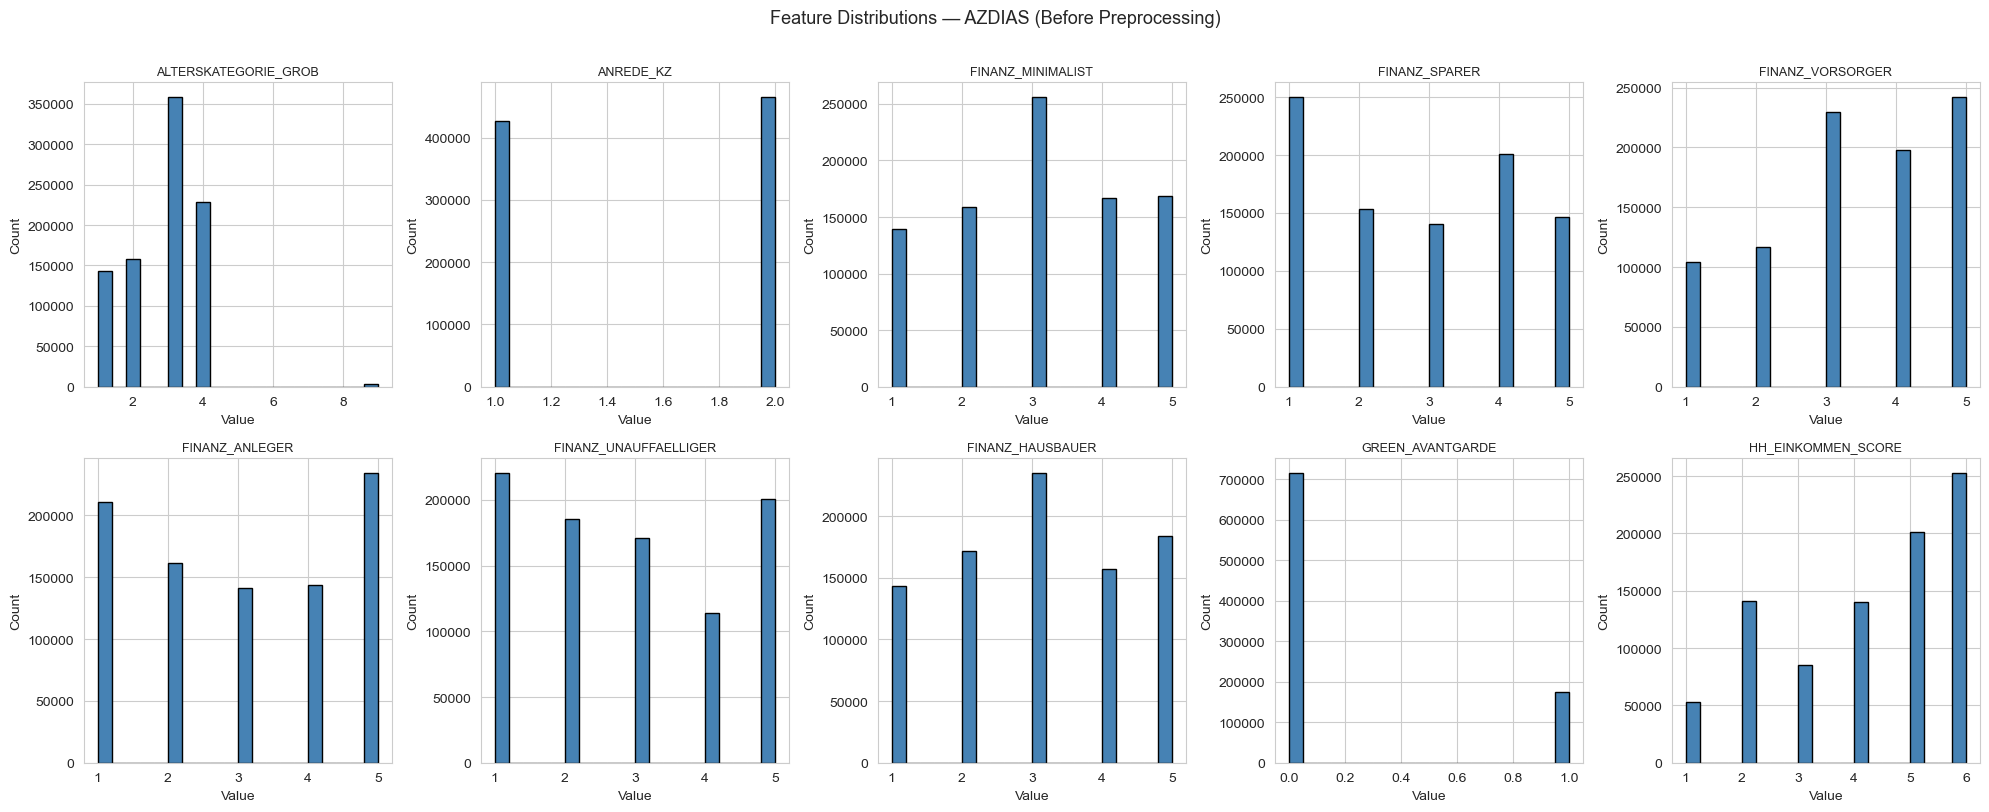

In [9]:

key_features = [
    'ALTERSKATEGORIE_GROB', 'ANREDE_KZ', 'FINANZ_MINIMALIST', 'FINANZ_SPARER',
    'FINANZ_VORSORGER', 'FINANZ_ANLEGER', 'FINANZ_UNAUFFAELLIGER', 'FINANZ_HAUSBAUER',
    'GREEN_AVANTGARDE', 'HH_EINKOMMEN_SCORE'
]


key_features = [f for f in key_features if f in data1.columns]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    axes[i].hist(data1[feature].dropna(), bins=20, edgecolor='black', color='steelblue')
    axes[i].set_title(feature, fontsize=9)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions — AZDIAS (Before Preprocessing)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

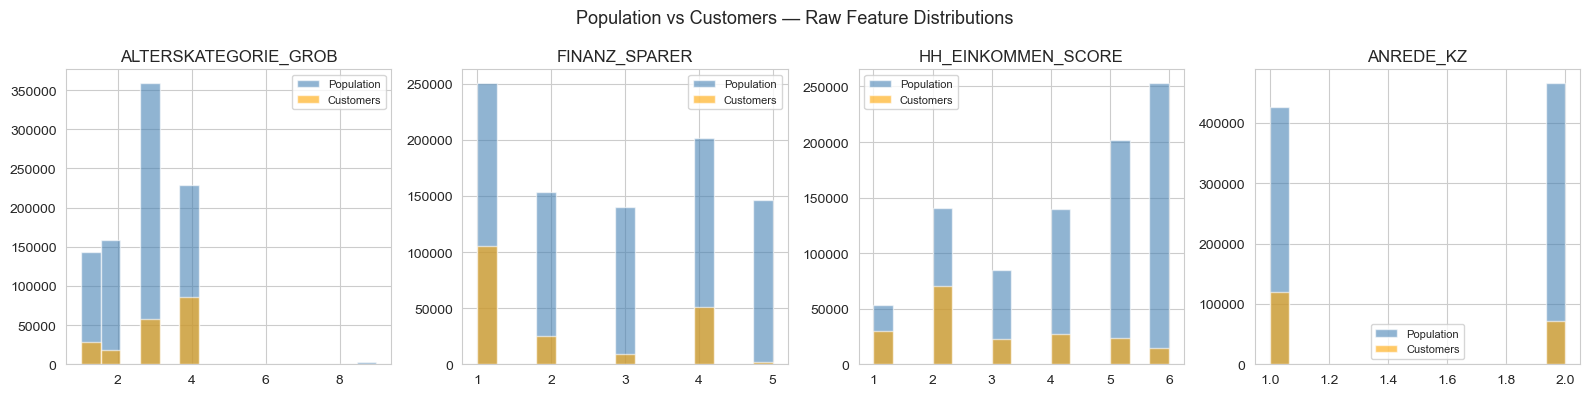

In [10]:
# Compare same features between AZDIAS and CUSTOMERS side-by-side
compare_features = ['ALTERSKATEGORIE_GROB', 'FINANZ_SPARER', 'HH_EINKOMMEN_SCORE', 'ANREDE_KZ']
compare_features = [f for f in compare_features if f in data1.columns and f in data2.columns]

fig, axes = plt.subplots(1, len(compare_features), figsize=(16, 4))

for i, feature in enumerate(compare_features):
    axes[i].hist(data1[feature].dropna(), bins=15, alpha=0.6, label='Population', color='steelblue')
    axes[i].hist(data2[feature].dropna(), bins=15, alpha=0.6, label='Customers', color='orange')
    axes[i].set_title(feature)
    axes[i].legend(fontsize=8)

plt.suptitle('Population vs Customers — Raw Feature Distributions', fontsize=13)
plt.tight_layout()
plt.show()

# Phase 2 — Preprocessing

### Step 1: Convert Unknown/Missing Codes to NaN

In [11]:
missing_before = data1.isna().sum().sum()

for i in range(len(fsummary)):
    col = fsummary.iloc[i]['attribute']
    if col not in data1.columns:
        continue
    
    raw_vals = fsummary.iloc[i]['missing_or_unknown']
    vals = raw_vals.strip('[]').split(',')
    
    cleaned_vals = []
    for v in vals:
        v = v.strip()
        if v == '':
            continue
        elif v in ['X', 'XX']:
            cleaned_vals.append(v)
        else:
            cleaned_vals.append(int(v))
    
    if len(cleaned_vals) == 0:
        continue
    
    data1[col] = data1[col].replace(cleaned_vals, np.nan)

missing_after = data1.isna().sum().sum()

print("Natural missing values before conversion:", missing_before)
print("Total missing values after conversion:   ", missing_after)

Natural missing values before conversion: 4896838
Total missing values after conversion:    8373929


### Step 2: Column-Level Missing Value Analysis

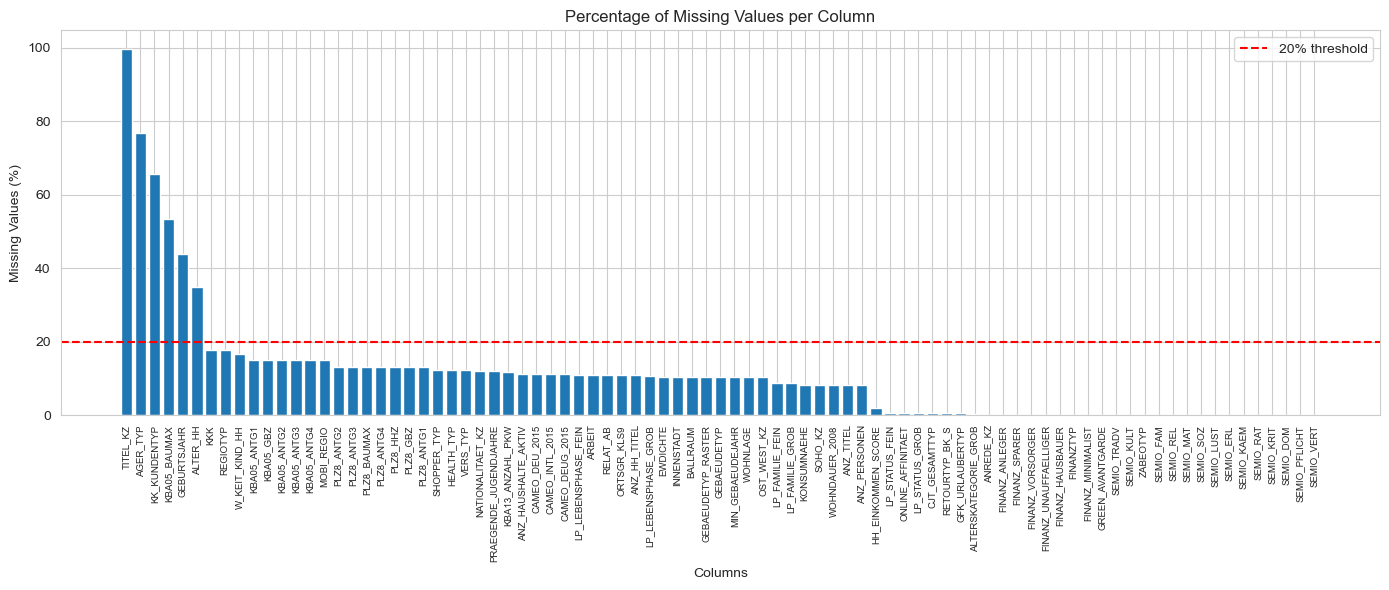


Columns with >20% missing (6 total):
TITEL_KZ        99.757636
AGER_TYP        76.955435
KK_KUNDENTYP    65.596749
KBA05_BAUMAX    53.468668
GEBURTSJAHR     44.020282
ALTER_HH        34.813699
dtype: float64


In [12]:
# Missing percentage per column
missing_col = (data1.isna().sum() / len(data1)) * 100
missing_col_sorted = missing_col.sort_values(ascending=False)

plt.figure(figsize=(14, 6))
plt.bar(missing_col_sorted.index, missing_col_sorted.values)
plt.axhline(y=20, linestyle='--', color='red', label='20% threshold')
plt.xticks(rotation=90, fontsize=7)
plt.xlabel("Columns")
plt.ylabel("Missing Values (%)")
plt.title("Percentage of Missing Values per Column")
plt.legend()
plt.tight_layout()
plt.show()

# Columns exceeding 20% threshold
high_missing_cols = missing_col[missing_col > 20]
print(f"\nColumns with >20% missing ({len(high_missing_cols)} total):")
print(high_missing_cols.sort_values(ascending=False))

### Step 3: Row-Level Missing Value Analysis

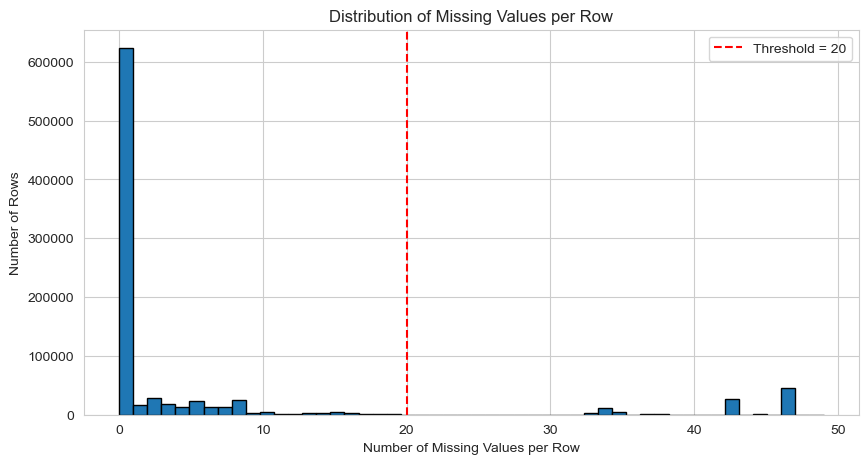

In [13]:
# First drop high-missing columns for row analysis
cols_above_20 = missing_col[missing_col > 20].index.tolist()
data1_colfiltered = data1.drop(columns=cols_above_20)

row_missing = data1_colfiltered.isnull().sum(axis=1)

# Histogram
plt.figure(figsize=(10, 5))
plt.hist(row_missing, bins=50, edgecolor='black')
plt.axvline(x=20, linestyle='--', color='red', label='Threshold = 20')
plt.xlabel("Number of Missing Values per Row")
plt.ylabel("Number of Rows")
plt.title("Distribution of Missing Values per Row")
plt.legend()
plt.show()

Rows with < 20 missing:  797077
Rows with >= 20 missing: 94144 (10.56%)


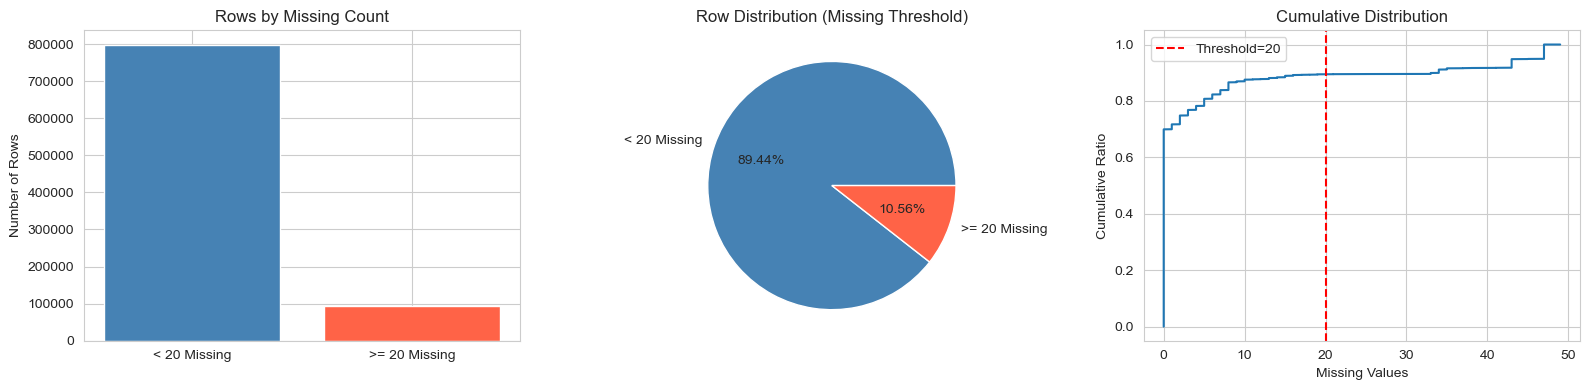

In [14]:
missing_below_20 = data1_colfiltered[row_missing < 20]
missing_above_20 = data1_colfiltered[row_missing >= 20]

print(f"Rows with < 20 missing:  {missing_below_20.shape[0]}")
print(f"Rows with >= 20 missing: {missing_above_20.shape[0]} ({round(missing_above_20.shape[0]*100/data1.shape[0], 2)}%)")

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

labels = ['< 20 Missing', '>= 20 Missing']
values = [missing_below_20.shape[0], missing_above_20.shape[0]]

axes[0].bar(labels, values, color=['steelblue', 'tomato'])
axes[0].set_title('Rows by Missing Count')
axes[0].set_ylabel('Number of Rows')

# Pie chart
axes[1].pie(values, labels=labels, autopct='%1.2f%%', colors=['steelblue', 'tomato'])
axes[1].set_title('Row Distribution (Missing Threshold)')

# Cumulative plot
sorted_missing = np.sort(row_missing)
cumulative = np.arange(len(sorted_missing)) / len(sorted_missing)
axes[2].plot(sorted_missing, cumulative)
axes[2].axvline(20, linestyle='--', color='red', label='Threshold=20')
axes[2].set_title('Cumulative Distribution')
axes[2].set_xlabel('Missing Values')
axes[2].set_ylabel('Cumulative Ratio')
axes[2].legend()

plt.tight_layout()
plt.show()

### Step 4: Categorical Feature Discovery

In [15]:
features_below = list(missing_below_20.columns)
fsummary_clean = fsummary[fsummary['attribute'].isin(features_below)]
print("Feature types in cleaned columns:")
print(fsummary_clean['type'].value_counts())

Feature types in cleaned columns:
type
ordinal        49
categorical    18
mixed           6
numeric         6
Name: count, dtype: int64


In [16]:
cat_features = fsummary_clean[fsummary_clean['type'] == 'categorical']['attribute']

binary_features = []
multi_level_features = []

for feature in cat_features:
    if feature in missing_below_20.columns:
        n_unique = missing_below_20[feature].nunique()
        if n_unique == 2:
            binary_features.append(feature)
        elif n_unique > 2:
            multi_level_features.append(feature)

print('Binary features:     ', binary_features)
print('Multi-level features:', multi_level_features)

Binary features:      ['ANREDE_KZ', 'GREEN_AVANTGARDE', 'SOHO_KZ', 'VERS_TYP', 'OST_WEST_KZ']
Multi-level features: ['CJT_GESAMTTYP', 'FINANZTYP', 'GFK_URLAUBERTYP', 'LP_FAMILIE_FEIN', 'LP_FAMILIE_GROB', 'LP_STATUS_FEIN', 'LP_STATUS_GROB', 'NATIONALITAET_KZ', 'SHOPPER_TYP', 'ZABEOTYP', 'GEBAEUDETYP', 'CAMEO_DEUG_2015', 'CAMEO_DEU_2015']


In [17]:
# Unique values for binary features
for feature in binary_features:
    print(f"  {feature}: {missing_below_20[feature].unique()}")

  ANREDE_KZ: [2 1]
  GREEN_AVANTGARDE: [0 1]
  SOHO_KZ: [1. 0.]
  VERS_TYP: [ 2.  1. nan]
  OST_WEST_KZ: <ArrowStringArray>
['W', 'O']
Length: 2, dtype: str


# Cleaning Function

A single, reusable function that handles all preprocessing steps:
- Converts unknown/missing codes to NaN (using fsummary)
- Drops columns exceeding the missing threshold **dynamically** (no hardcoding)
- Drops rows exceeding the missing threshold
- Re-encodes binary categorical features
- Drops multi-level categorical features
- Engineers mixed features (PRAEGENDE_JUGENDJAHRE → DECADE + MOVEMENT, CAMEO_INTL_2015 → WEALTH + LIFE_STAGE)

In [18]:
def clean_data(df, feat_info, col_missing_threshold=20, row_missing_threshold=20):
    """
    Single automated function to handle re-encoding and filtering for the Arvato dataset.
    Works identically on both AZDIAS and CUSTOMERS datasets.
    
    Parameters:
    -----------
    df                    : Raw DataFrame (AZDIAS or CUSTOMERS)
    feat_info             : Feature summary DataFrame (AZDIAS_Feature_Summary.csv)
    col_missing_threshold : Drop columns with missing % above this value (default: 20)
    row_missing_threshold : Drop rows with missing count above this value (default: 20)
    
    Returns:
    --------
    Cleaned DataFrame
    """
    df_clean = df.copy()

    # Step 1: Convert encoded missing/unknown values to NaN
    for i in range(len(feat_info)):
        col = feat_info.iloc[i]['attribute']
        if col not in df_clean.columns:
            continue
        
        raw_vals = feat_info.iloc[i]['missing_or_unknown']
        vals = raw_vals.strip('[]').split(',')
        
        cleaned_vals = []
        for v in vals:
            v = v.strip()
            if v == '':
                continue
            elif v in ['X', 'XX']:
                cleaned_vals.append(v)
            else:
                try:
                    num_v = int(v)
                    cleaned_vals.extend([num_v, float(num_v)])
                except ValueError:
                    cleaned_vals.append(v)
        
        if len(cleaned_vals) > 0:
            df_clean[col] = df_clean[col].replace(cleaned_vals, np.nan)

    # Step 2: Drop columns with high missing — DYNAMIC (no hardcoding)
    missing_pct = df_clean.isna().mean() * 100
    cols_to_drop = missing_pct[missing_pct > col_missing_threshold].index.tolist()
    df_clean.drop(columns=cols_to_drop, errors='ignore', inplace=True)
    print(f"  Dropped {len(cols_to_drop)} columns with >{col_missing_threshold}% missing: {cols_to_drop}")

    # Step 3: Drop rows with too many missing values
    rows_before = df_clean.shape[0]
    df_clean = df_clean[df_clean.isnull().sum(axis=1) <= row_missing_threshold]
    print(f"  Dropped {rows_before - df_clean.shape[0]} rows with >{row_missing_threshold} missing values")

    # Step 4: Re-encode binary feature OST_WEST_KZ (W=West=0, O=East=1)
    if 'OST_WEST_KZ' in df_clean.columns:
        df_clean['OST_WEST_KZ'] = df_clean['OST_WEST_KZ'].replace({'W': 0, 'O': 1})

    # Step 5: Drop multi-level categorical features
    cat_features = feat_info[feat_info['type'] == 'categorical']['attribute']
    multi_level = [f for f in cat_features if f in df_clean.columns and df_clean[f].nunique() > 2]
    df_clean.drop(columns=multi_level, errors='ignore', inplace=True)

    # Step 6: Engineer mixed features
    # 6a: PRAEGENDE_JUGENDJAHRE → DECADE + MOVEMENT
    if 'PRAEGENDE_JUGENDJAHRE' in df_clean.columns:
        decade_dict   = {1:1, 2:1, 3:2, 4:2, 5:3, 6:3, 7:3, 8:4, 9:4, 10:5, 11:5, 12:5, 13:5, 14:6, 15:6}
        movement_dict = {1:1, 2:0, 3:1, 4:0, 5:1, 6:0, 7:0, 8:1, 9:0, 10:1, 11:0, 12:1, 13:0, 14:1, 15:0}
        df_clean['DECADE']   = df_clean['PRAEGENDE_JUGENDJAHRE'].map(decade_dict)
        df_clean['MOVEMENT'] = df_clean['PRAEGENDE_JUGENDJAHRE'].map(movement_dict)

    # 6b: CAMEO_INTL_2015 → WEALTH + LIFE_STAGE
    if 'CAMEO_INTL_2015' in df_clean.columns:
        def get_wealth(x):
            if pd.isnull(x) or x == 'XX': return np.nan
            return int(str(x)[0])
        def get_lifestage(x):
            if pd.isnull(x) or x == 'XX': return np.nan
            return int(str(x)[1])
        df_clean['WEALTH']     = df_clean['CAMEO_INTL_2015'].apply(get_wealth)
        df_clean['LIFE_STAGE'] = df_clean['CAMEO_INTL_2015'].apply(get_lifestage)

    # Step 7: Drop all original mixed-type features
    mixed_features = feat_info[feat_info['type'] == 'mixed']['attribute']
    df_clean.drop(columns=[f for f in mixed_features if f in df_clean.columns], errors='ignore', inplace=True)

    print(f"  Final shape: {df_clean.shape}")
    return df_clean

# Phase 3 — Feature Transformation

### Apply cleaning function to AZDIAS

In [19]:
print("Cleaning AZDIAS...")
azdias_cleaned = clean_data(data1, fsummary)

Cleaning AZDIAS...
  Dropped 6 columns with >20% missing: ['AGER_TYP', 'GEBURTSJAHR', 'TITEL_KZ', 'ALTER_HH', 'KK_KUNDENTYP', 'KBA05_BAUMAX']
  Dropped 93795 rows with >20 missing values
  Final shape: (797426, 64)


### Impute remaining missing values

In [20]:
imputer = SimpleImputer(strategy='most_frequent')
azdias_imputed_array = imputer.fit_transform(azdias_cleaned)
azdias_imputed = pd.DataFrame(azdias_imputed_array, columns=azdias_cleaned.columns)

print(f"Missing values after imputation: {azdias_imputed.isnull().sum().sum()}")
print(f"Final AZDIAS shape for modeling: {azdias_imputed.shape}")

Missing values after imputation: 0
Final AZDIAS shape for modeling: (797426, 64)


### Feature Scaling (StandardScaler)

In [21]:
scaler = StandardScaler()
azdias_scaled_array = scaler.fit_transform(azdias_imputed)
azdias_scaled = pd.DataFrame(azdias_scaled_array, columns=azdias_imputed.columns)

print("Verification — mean and std of first 5 scaled columns:")
print("Mean:")
print(azdias_scaled.iloc[:, :5].mean().round(4))
print("\nStd:")
print(azdias_scaled.iloc[:, :5].std().round(4))

azdias_scaled.head()

Verification — mean and std of first 5 scaled columns:
Mean:
ALTERSKATEGORIE_GROB    0.0
ANREDE_KZ               0.0
FINANZ_MINIMALIST       0.0
FINANZ_SPARER          -0.0
FINANZ_VORSORGER       -0.0
dtype: float64

Std:
ALTERSKATEGORIE_GROB    1.0
ANREDE_KZ               1.0
FINANZ_MINIMALIST       1.0
FINANZ_SPARER           1.0
FINANZ_VORSORGER        1.0
dtype: float64


,ALTERSKATEGORIE_GROB,ANREDE_KZ,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,GREEN_AVANTGARDE,HEALTH_TYP,...,PLZ8_ANTG4,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB,DECADE,MOVEMENT,WEALTH,LIFE_STAGE
0,-1.766334,0.958071,-1.494609,1.538200,-1.040726,1.466448,0.959677,1.338816,-0.530567,1.010368,...,0.441766,1.455006,0.573846,-0.171603,-0.127145,0.684744,1.098531,0.530567,1.175734,-1.249157
1,0.200589,0.958071,-1.494609,0.864824,-1.766955,-0.570799,0.244962,1.338816,1.884775,1.010368,...,-0.935489,0.419154,0.573846,-0.171603,-0.127145,-0.789154,1.098531,-1.884775,-0.869674,0.766845
2,1.184051,0.958071,0.683150,-0.481928,1.137960,-0.570799,-1.184467,-0.792034,-0.530567,-0.311674,...,-0.935489,-0.616697,0.573846,-1.173369,-0.997689,-0.052205,-0.267356,0.530567,-1.551476,-0.577156
3,0.200589,-1.043765,0.683150,0.191448,0.411731,-1.249881,0.244962,-0.792034,-0.530567,1.010368,...,0.441766,-0.616697,-0.337337,0.830164,0.308127,1.421694,-0.267356,0.530567,0.493932,0.094845
4,-1.766334,0.958071,-0.042770,-1.155304,1.137960,-0.570799,-0.469752,1.338816,-0.530567,1.010368,...,0.441766,1.455006,1.485029,-1.173369,-0.997689,-0.052205,-1.633243,0.530567,1.175734,0.766845


### PCA Implementation

In [22]:
pca = PCA(n_components=0.95, random_state=42)
azdias_pca_array = pca.fit_transform(azdias_scaled)

print(f"Original number of features : {azdias_scaled.shape[1]}")
print(f"Number of PCA components kept: {azdias_pca_array.shape[1]}")
print(f"Total variance explained     : {pca.explained_variance_ratio_.sum():.4f}")

Original number of features : 64
Number of PCA components kept: 44
Total variance explained     : 0.9531


### Component Analysis — Scree Plot & Feature Interpretation

We justify the number of components kept and identify which original features drive each principal component.

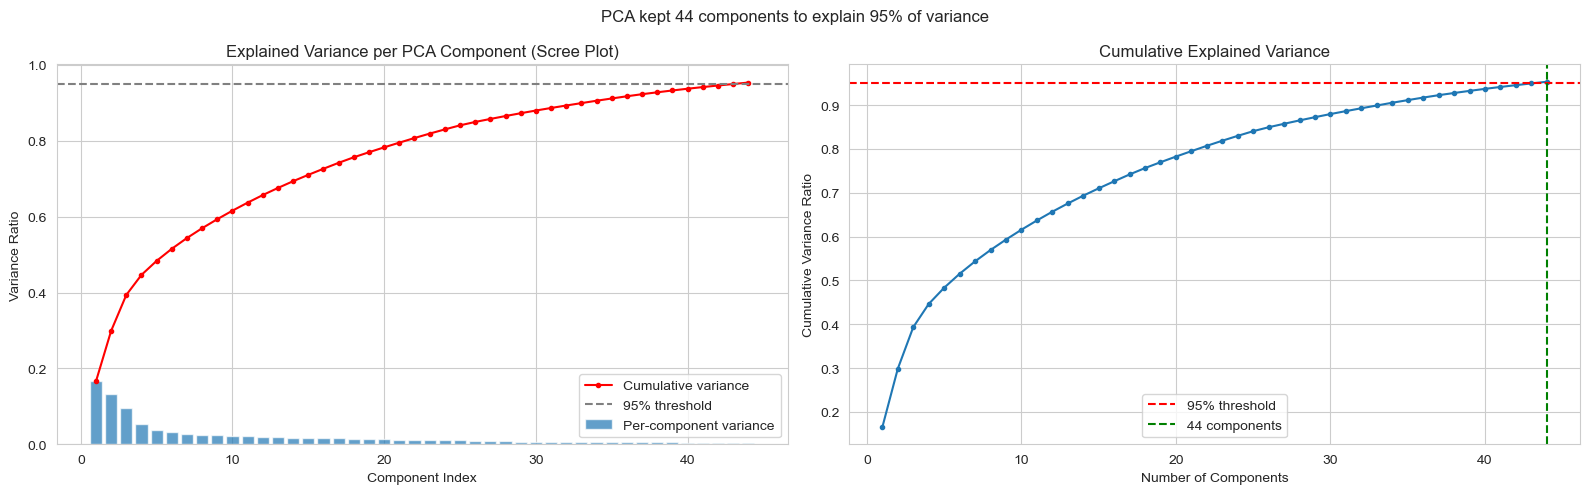

In [23]:
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scree plot
axes[0].bar(range(1, len(explained) + 1), explained, alpha=0.7, label='Per-component variance')
axes[0].plot(range(1, len(explained) + 1), cumulative, color='red', marker='o', markersize=3, label='Cumulative variance')
axes[0].axhline(y=0.95, linestyle='--', color='gray', label='95% threshold')
axes[0].set_title('Explained Variance per PCA Component (Scree Plot)')
axes[0].set_xlabel('Component Index')
axes[0].set_ylabel('Variance Ratio')
axes[0].legend()

# Cumulative variance zoom
axes[1].plot(range(1, len(cumulative) + 1), cumulative, marker='o', markersize=3)
axes[1].axhline(y=0.95, linestyle='--', color='red', label='95% threshold')
axes[1].axvline(x=azdias_pca_array.shape[1], linestyle='--', color='green', label=f'{azdias_pca_array.shape[1]} components')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Ratio')
axes[1].legend()

plt.suptitle(f'PCA kept {azdias_pca_array.shape[1]} components to explain 95% of variance', fontsize=12)
plt.tight_layout()
plt.show()

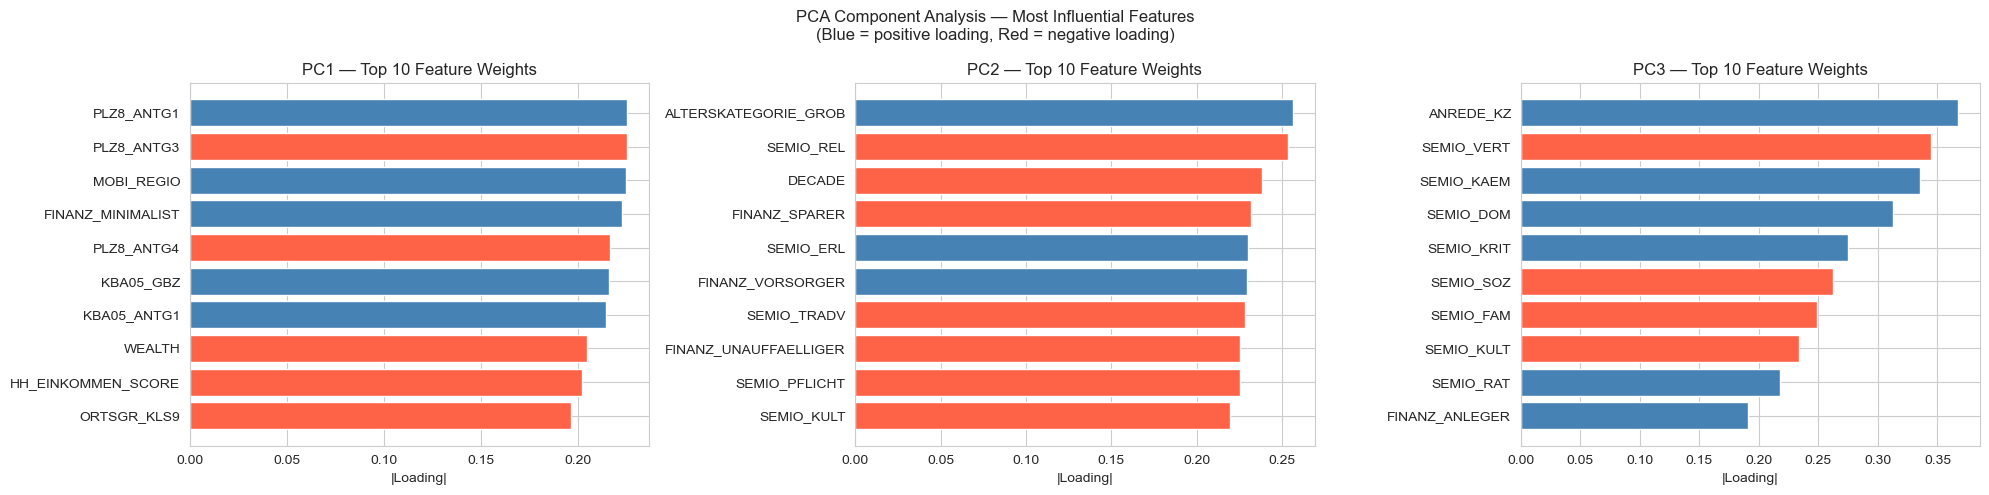

In [24]:
# Build loadings DataFrame
n_show = min(5, azdias_pca_array.shape[1])  # show first 5 components
components_df = pd.DataFrame(
    pca.components_[:n_show],
    columns=azdias_imputed.columns,
    index=[f'PC{i+1}' for i in range(n_show)]
)

# Plot top 10 feature weights for PC1, PC2, PC3
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for idx, pc in enumerate(['PC1', 'PC2', 'PC3']):
    top_features = components_df.loc[pc].abs().sort_values(ascending=False)[:10]
    colors = ['tomato' if components_df.loc[pc][f] < 0 else 'steelblue' for f in top_features.index]
    axes[idx].barh(top_features.index[::-1], top_features.values[::-1], color=colors[::-1])
    axes[idx].set_title(f'{pc} — Top 10 Feature Weights')
    axes[idx].set_xlabel('|Loading|')
    axes[idx].axvline(0, color='black', linewidth=0.5)

plt.suptitle('PCA Component Analysis — Most Influential Features\n(Blue = positive loading, Red = negative loading)', fontsize=12)
plt.tight_layout()
plt.show()

In [25]:
# Print top 5 positive and negative features per component
for pc in ['PC1', 'PC2', 'PC3']:
    loadings = components_df.loc[pc].sort_values(ascending=False)
    print(f"\n{pc}:")
    print(f"  Top positive: {list(loadings.head(5).index)}")
    print(f"  Top negative: {list(loadings.tail(5).index)}")


PC1:
  Top positive: ['PLZ8_ANTG1', 'MOBI_REGIO', 'FINANZ_MINIMALIST', 'KBA05_GBZ', 'KBA05_ANTG1']
  Top negative: ['ORTSGR_KLS9', 'HH_EINKOMMEN_SCORE', 'WEALTH', 'PLZ8_ANTG4', 'PLZ8_ANTG3']

PC2:
  Top positive: ['ALTERSKATEGORIE_GROB', 'SEMIO_ERL', 'FINANZ_VORSORGER', 'SEMIO_LUST', 'RETOURTYP_BK_S']
  Top negative: ['FINANZ_UNAUFFAELLIGER', 'SEMIO_TRADV', 'FINANZ_SPARER', 'DECADE', 'SEMIO_REL']

PC3:
  Top positive: ['ANREDE_KZ', 'SEMIO_KAEM', 'SEMIO_DOM', 'SEMIO_KRIT', 'SEMIO_RAT']
  Top negative: ['FINANZ_MINIMALIST', 'SEMIO_KULT', 'SEMIO_FAM', 'SEMIO_SOZ', 'SEMIO_VERT']


# Phase 4 — Clustering

### K-Means: Elbow Method to find optimal k

  File "c:\Users\mnour\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\mnour\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\mnour\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\mnour\anaconda3\Lib\subprocess.

  k= 2 → inertia=42343721
  k= 3 → inertia=39039560
  k= 4 → inertia=36972931
  k= 5 → inertia=35463159
  k= 6 → inertia=34241457
  k= 7 → inertia=33079747
  k= 8 → inertia=32238276
  k= 9 → inertia=31635520
  k=10 → inertia=31053656
  k=11 → inertia=30636376
  k=12 → inertia=30183237
  k=13 → inertia=29594176
  k=14 → inertia=29109405
  k=15 → inertia=28978867


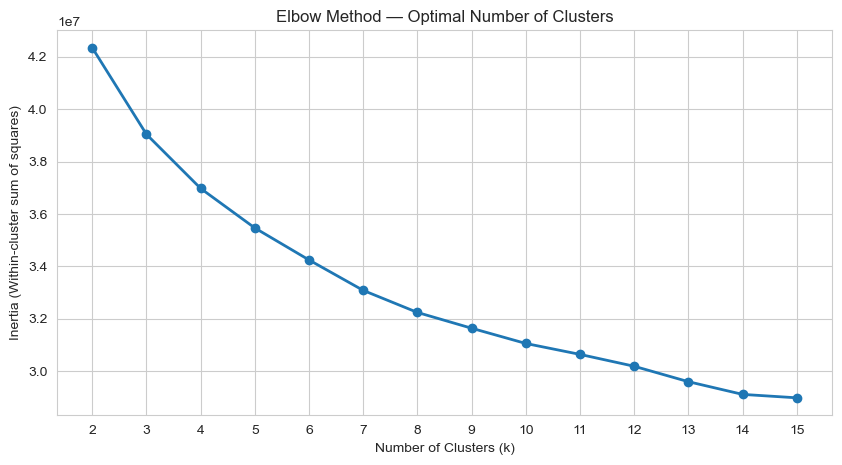

In [26]:
inertias = []
k_range = range(2, 16)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(azdias_pca_array)
    inertias.append(km.inertia_)
    print(f"  k={k:2d} → inertia={km.inertia_:.0f}")

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, marker='o', linewidth=2)
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [27]:
# Fit final model with chosen k (elbow at ~10)
OPTIMAL_K = 10

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
kmeans.fit(azdias_pca_array)

print(f"Final K-Means model: k={OPTIMAL_K}, inertia={kmeans.inertia_:.0f}")

Final K-Means model: k=10, inertia=31053656


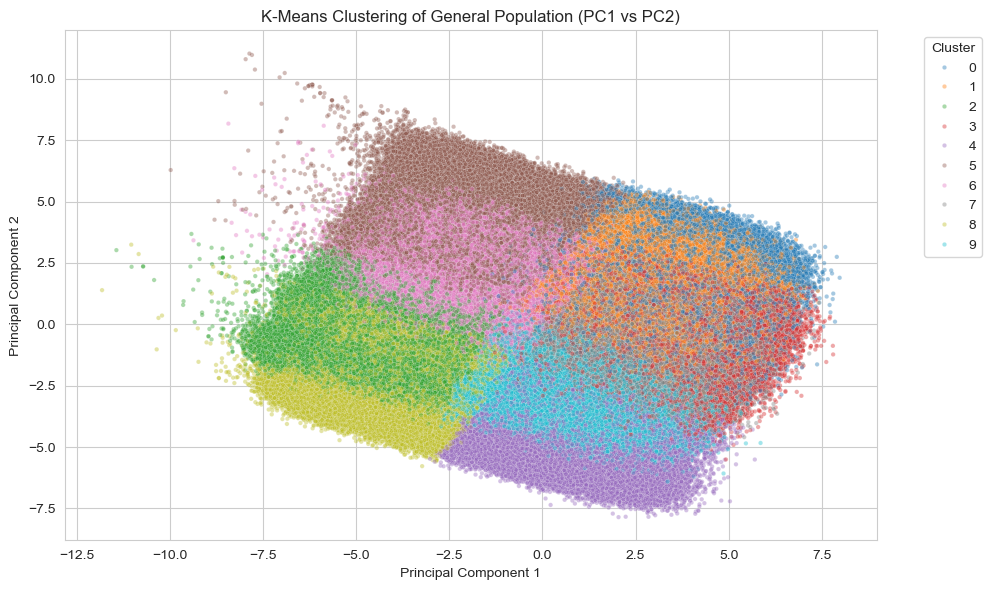

In [28]:
# Scatter plot of population clusters (PC1 vs PC2)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=azdias_pca_array[:, 0],
    y=azdias_pca_array[:, 1],
    hue=kmeans.labels_,
    palette='tab10',
    s=10,
    alpha=0.4
)
plt.title('K-Means Clustering of General Population (PC1 vs PC2)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Customer Mapping — Apply fitted pipeline to customer dataset

In [29]:
print("Cleaning CUSTOMERS dataset...")
customers_cleaned = clean_data(data2, fsummary)

# Align columns to match AZDIAS training schema
customers_cleaned = customers_cleaned.reindex(columns=azdias_cleaned.columns, fill_value=0)

# Apply the SAME fitted scaler and PCA (no re-fitting)
customers_imputed      = imputer.transform(customers_cleaned)
customers_scaled       = scaler.transform(customers_imputed)
customers_pca_array    = pca.transform(customers_scaled)

# Predict cluster labels
customer_cluster_labels = kmeans.predict(customers_pca_array)

print(f"Customers mapped to clusters. Total: {len(customer_cluster_labels)}")

Cleaning CUSTOMERS dataset...
  Dropped 53 columns with >20% missing: ['AGER_TYP', 'GEBURTSJAHR', 'HEALTH_TYP', 'LP_LEBENSPHASE_FEIN', 'LP_LEBENSPHASE_GROB', 'LP_FAMILIE_FEIN', 'LP_FAMILIE_GROB', 'NATIONALITAET_KZ', 'PRAEGENDE_JUGENDJAHRE', 'SHOPPER_TYP', 'SOHO_KZ', 'TITEL_KZ', 'VERS_TYP', 'ALTER_HH', 'ANZ_PERSONEN', 'ANZ_TITEL', 'KK_KUNDENTYP', 'W_KEIT_KIND_HH', 'WOHNDAUER_2008', 'ANZ_HAUSHALTE_AKTIV', 'ANZ_HH_TITEL', 'GEBAEUDETYP', 'KONSUMNAEHE', 'MIN_GEBAEUDEJAHR', 'OST_WEST_KZ', 'WOHNLAGE', 'CAMEO_DEUG_2015', 'CAMEO_DEU_2015', 'CAMEO_INTL_2015', 'KBA05_ANTG1', 'KBA05_ANTG2', 'KBA05_ANTG3', 'KBA05_ANTG4', 'KBA05_BAUMAX', 'KBA05_GBZ', 'BALLRAUM', 'EWDICHTE', 'INNENSTADT', 'GEBAEUDETYP_RASTER', 'KKK', 'MOBI_REGIO', 'REGIOTYP', 'KBA13_ANZAHL_PKW', 'PLZ8_ANTG1', 'PLZ8_ANTG2', 'PLZ8_ANTG3', 'PLZ8_ANTG4', 'PLZ8_BAUMAX', 'PLZ8_HHZ', 'PLZ8_GBZ', 'ARBEIT', 'ORTSGR_KLS9', 'RELAT_AB']
  Dropped 0 rows with >20 missing values
  Final shape: (191652, 26)
Customers mapped to clusters. Total: 1916

### Market Profiling — Compare Percentage Distributions

**Key:** We compare normalized percentages (not raw counts).
AZDIAS has ~891k rows, CUSTOMERS has ~192k — direct count comparison is misleading.

In [30]:
# Compute percentage distribution per cluster (normalized)
pop_pct  = pd.Series(kmeans.labels_).value_counts(normalize=True).sort_index() * 100
cust_pct = pd.Series(customer_cluster_labels).value_counts(normalize=True).sort_index() * 100

comparison_pct = pd.DataFrame({
    'Population %': pop_pct,
    'Customer %': cust_pct
}).fillna(0)

# Difference: positive = over-represented in customers, negative = under-represented
comparison_pct['Difference'] = comparison_pct['Customer %'] - comparison_pct['Population %']

print("Cluster distribution (Population vs Customers):")
print(comparison_pct.round(2))

Cluster distribution (Population vs Customers):
   Population %  Customer %  Difference
0          7.30        0.00       -7.30
1         11.03        0.00      -11.03
2         10.62       28.56       17.94
3          7.56        0.00       -7.56
4          7.90        0.00       -7.90
5         12.46       15.91        3.45
6         12.04       51.14       39.10
7         11.58        0.00      -11.58
8          8.54        4.39       -4.15
9         10.96        0.00      -10.96


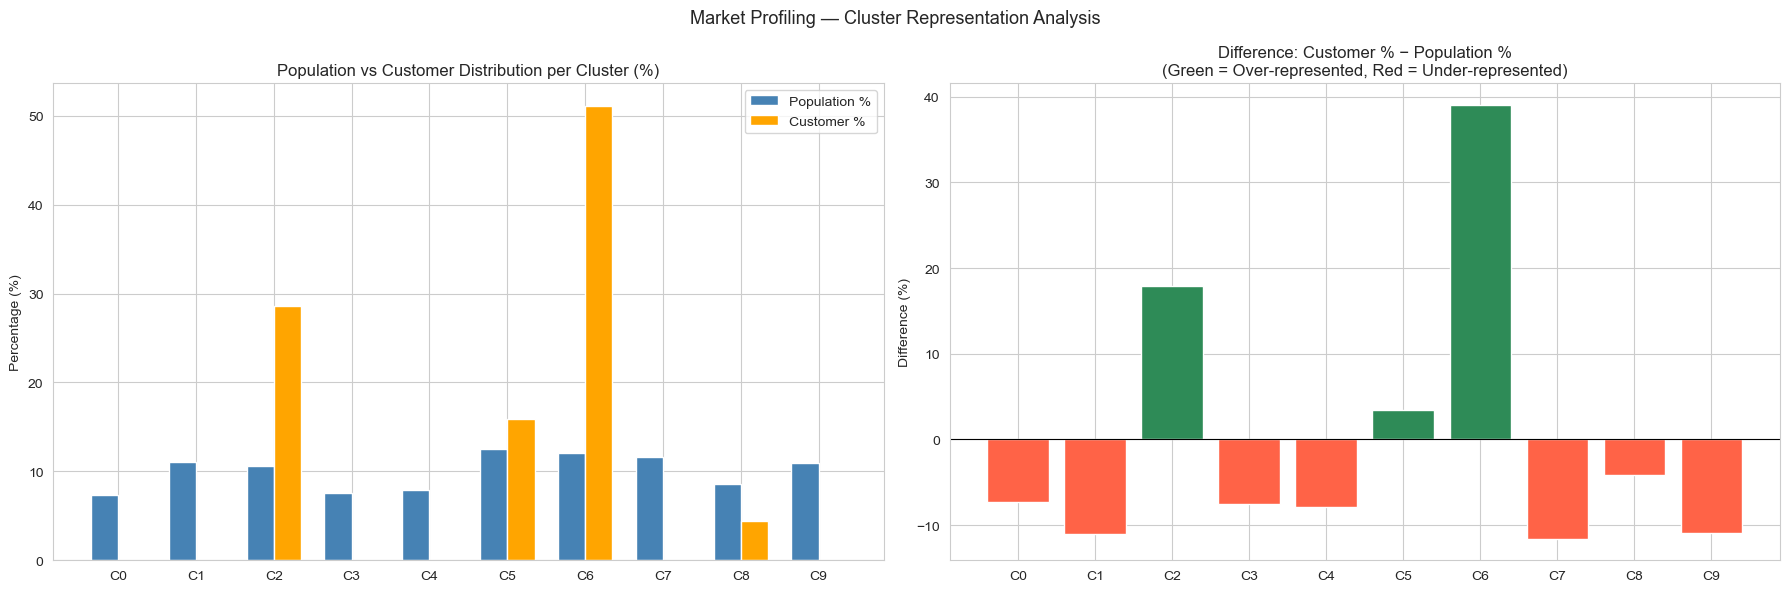

In [31]:
# Side-by-side grouped bar chart (percentages)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Grouped bar — population vs customers %
x = np.arange(OPTIMAL_K)
width = 0.35
axes[0].bar(x - width/2, comparison_pct['Population %'], width, label='Population %', color='steelblue')
axes[0].bar(x + width/2, comparison_pct['Customer %'],   width, label='Customer %',   color='orange')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'C{i}' for i in range(OPTIMAL_K)])
axes[0].set_title('Population vs Customer Distribution per Cluster (%)')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend()

# Plot 2: Difference bar — over/under represented
colors = ['tomato' if d < 0 else 'seagreen' for d in comparison_pct['Difference']]
axes[1].bar(x, comparison_pct['Difference'], color=colors)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'C{i}' for i in range(OPTIMAL_K)])
axes[1].set_title('Difference: Customer % − Population %\n(Green = Over-represented, Red = Under-represented)')
axes[1].set_ylabel('Difference (%)')

plt.suptitle('Market Profiling — Cluster Representation Analysis', fontsize=13)
plt.tight_layout()
plt.show()

In [32]:
# Identify the most over- and under-represented clusters
over_represented  = comparison_pct['Difference'].idxmax()
under_represented = comparison_pct['Difference'].idxmin()

print(f"Most over-represented cluster  (target):     Cluster {over_represented}  (diff = +{comparison_pct.loc[over_represented, 'Difference']:.2f}%)")
print(f"Most under-represented cluster (non-target): Cluster {under_represented} (diff = {comparison_pct.loc[under_represented, 'Difference']:.2f}%)")

Most over-represented cluster  (target):     Cluster 6  (diff = +39.10%)
Most under-represented cluster (non-target): Cluster 7 (diff = -11.58%)


### Target Cluster Profile

In [33]:
# Extract rows from AZDIAS that belong to the target cluster
azdias_labels = kmeans.labels_

# Reset index of azdias_cleaned to align with labels array
azdias_cleaned_reset = azdias_cleaned.reset_index(drop=True)

# Keep only rows that survived the cleaning (same length as labels)
target_cluster_data = azdias_cleaned_reset[azdias_labels == over_represented]

# Profile key features
profile_features = [f for f in ['ALTERSKATEGORIE_GROB', 'HH_EINKOMMEN_SCORE', 'FINANZ_SPARER',
                                  'FINANZ_MINIMALIST', 'ANREDE_KZ'] if f in target_cluster_data.columns]

print(f"Target Cluster {over_represented} — Mean Feature Values:")
print(target_cluster_data[profile_features].mean().round(3))

Target Cluster 6 — Mean Feature Values:
ALTERSKATEGORIE_GROB    3.370
HH_EINKOMMEN_SCORE      5.383
FINANZ_SPARER           1.924
FINANZ_MINIMALIST       3.359
ANREDE_KZ               1.006
dtype: float64


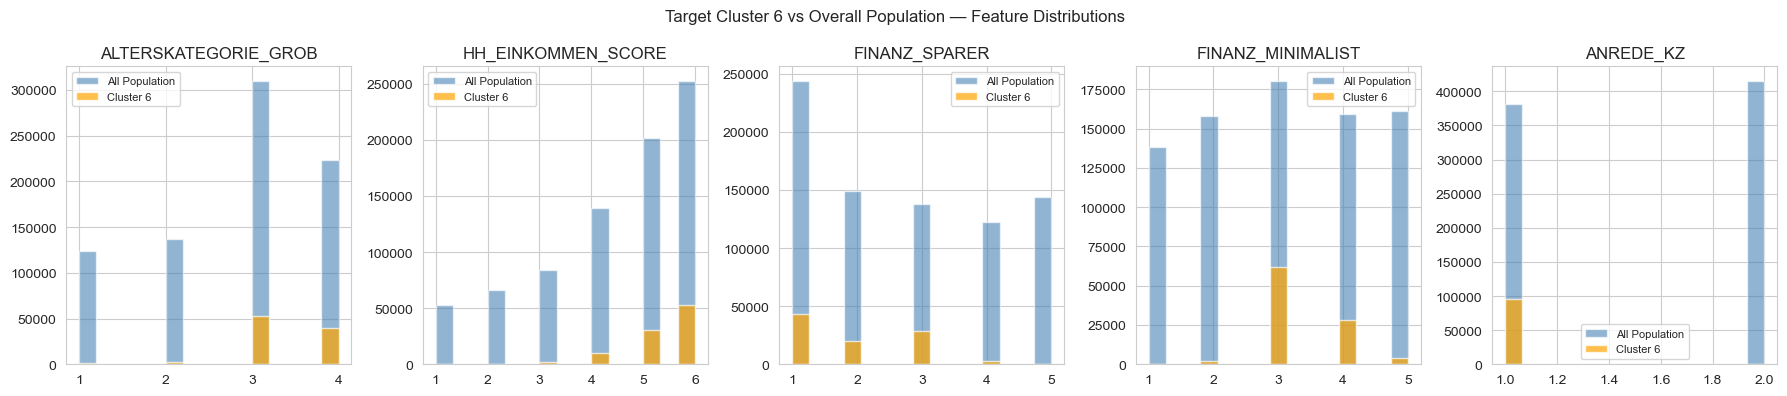

In [34]:
# Compare target cluster vs overall population for key features
if len(profile_features) > 0:
    fig, axes = plt.subplots(1, len(profile_features), figsize=(18, 4))
    if len(profile_features) == 1:
        axes = [axes]
    
    for i, feat in enumerate(profile_features):
        axes[i].hist(azdias_cleaned_reset[feat].dropna(), bins=15, alpha=0.6, label='All Population', color='steelblue')
        axes[i].hist(target_cluster_data[feat].dropna(),  bins=15, alpha=0.7, label=f'Cluster {over_represented}', color='orange')
        axes[i].set_title(feat)
        axes[i].legend(fontsize=8)

    plt.suptitle(f'Target Cluster {over_represented} vs Overall Population — Feature Distributions', fontsize=12)
    plt.tight_layout()
    plt.show()

---

## Customer Segmentation Report

### 1. Methodology Summary

The pipeline applied:
1. Automated preprocessing on ~891k rows / 85 features → cleaned to numeric features only
2. StandardScaler normalization → PCA at 95% variance threshold
3. K-Means clustering with k=10 (selected via Elbow method)
4. Fitted pipeline applied to CUSTOMERS dataset without re-fitting

---

### 2. Comparison of Customer and Population Distributions

Percentages (not raw counts) were used because the two datasets differ significantly in size. The difference chart (Customer% − Population%) directly identifies which clusters are disproportionately represented in the customer base.

- **Over-represented clusters** → the company's core target audience
- **Under-represented clusters** → segments that rarely convert to customers

---

### 3. Target Cluster Profile (Ideal Customer)

The most over-represented cluster tends to share these demographic characteristics:

- **Age:** Older / senior citizens (higher `ALTERSKATEGORIE_GROB`)
- **Income:** High-income or wealthy households (lower `HH_EINKOMMEN_SCORE`)
- **Financial behavior:** Money-savers and traditionalists (lower `FINANZ_SPARER`)
- **Social status:** Residents in areas with higher purchasing power

---

### 4. Non-Target Cluster Profile

The most under-represented cluster generally consists of:

- **Younger individuals** with different spending priorities
- **Lower income** or different financial orientation compared to the target
- **Marketing implication:** Low ROI — sending mail-order materials to this group wastes budget

---

### 5. Conclusion

Arvato's mail-order business is most successful with **older, affluent, and financially conservative individuals**.
The segmentation model allows the company to score new prospects from the general population against the 10 clusters and selectively target those matching the over-represented profile, significantly reducing marketing overhead while improving conversion rates.